In [30]:
import pandas as pd
import glob

files = glob.glob("/Users/jessicachen/Desktop/Output_file/*.csv")

df_list = [pd.read_csv(f) for f in files]

df_all = pd.concat(df_list, ignore_index=True)

df_all.to_csv("results_all.csv", index=False)

In [32]:
print(df_all.head())

   chunk_id    source_type document           model prompt_type  \
0         1  return_policy    Apple  gemini-2.5-pro    baseline   
1         2  return_policy    Apple  gemini-2.5-pro    baseline   
2         3  return_policy    Apple  gemini-2.5-pro    baseline   
3         4  return_policy    Apple  gemini-2.5-pro    baseline   
4         5  return_policy    Apple  gemini-2.5-pro    baseline   

                                            question  \
0  What is the time frame for returning an undama...   
1  What form of compensation is offered for an it...   
2  What happens to your wireless service account ...   
3  What happens if an iPhone requires repair due ...   
4  What happens if Apple cancels an order after y...   

                                              answer  
0  An undamaged product can be returned within 14...  
1  Apple will offer an Apple Gift Card for items ...  
2  Returning your device may not automatically ca...  
3  The repair will not be covered under 

In [34]:
print(df_all.shape)

(1248, 7)


In [36]:
df_results = pd.read_csv("results_all.csv",encoding="latin1")
df_chunks = pd.read_csv("All_chunks.csv", encoding="latin1")

df_all = df_results.merge(df_chunks, on="chunk_id", how="left")

In [38]:
df_all.to_csv("results.csv", index=False)

#### Answer length

In [41]:
import pandas as pd

df = pd.read_csv("results.csv")

# 计算答案长度
df["answer_length"] = df["answer"].apply(lambda x: len(str(x).split()))

# 按模型看平均长度
print("\nAverage answer length by model:")
print(df.groupby("model")["answer_length"].mean())

# 按prompt看
print("\nAverage answer length by prompt:")
print(df.groupby(["model", "prompt_type"])["answer_length"].mean())


Average answer length by model:
model
gemini-2.5-flash    15.243590
gemini-2.5-pro      28.669872
gpt-4o-mini         21.608974
mistral-large       28.157051
Name: answer_length, dtype: float64

Average answer length by prompt:
model             prompt_type    
gemini-2.5-flash  baseline            9.759615
                  concise             8.000000
                  key_information    27.971154
gemini-2.5-pro    baseline           15.875000
                  concise            14.115385
                  key_information    56.019231
gpt-4o-mini       baseline           16.778846
                  concise            14.663462
                  key_information    33.384615
mistral-large     baseline           14.115385
                  concise            10.471154
                  key_information    59.884615
Name: answer_length, dtype: float64


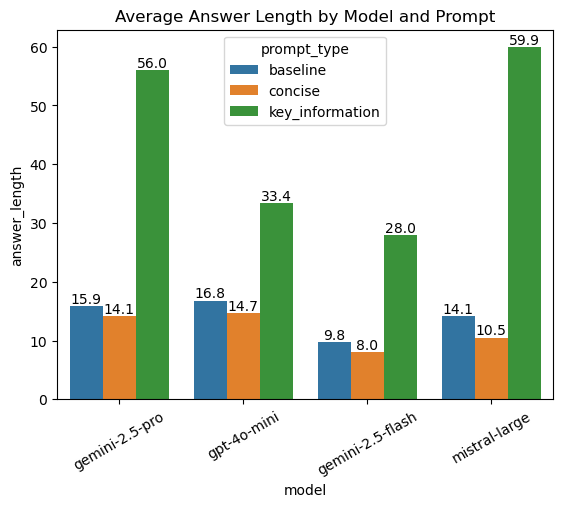

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()

ax = sns.barplot(
    data=df,
    x="model",
    y="answer_length",
    hue="prompt_type",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Average Answer Length by Model and Prompt")
plt.xticks(rotation=30)

plt.show()

In [44]:
print(df.groupby("source_type")["answer_length"].mean())

source_type
Wiki             23.329861
macro_policy     26.634409
return_policy    20.408333
syllabus         19.072222
Name: answer_length, dtype: float64


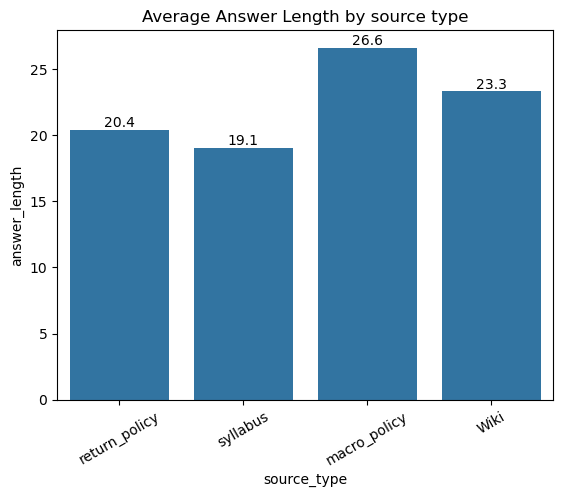

In [45]:
plt.figure()
ax=sns.barplot(data=df, x="source_type", y="answer_length",errorbar=None)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Average Answer Length by source type")
plt.xticks(rotation=30)

plt.show()

#### Effectiveness score

In [50]:
import re

stopwords = {
    "the","a","an","and","or","but","if","in","on","at","to","for","of","with",
    "by","is","are","was","were","be","been","being","this","that","these","those",
    "it","its","as","from","into","about","can","could","should","would","will",
    "may","might","do","does","did","have","has","had"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    return [w for w in words if w not in stopwords]

def overlap(row):
    text_words = set(clean_text(row["text"]))
    answer_words = set(clean_text(row["answer"]))
    if len(answer_words) == 0:
        return 0
    return len(text_words & answer_words) / len(answer_words)

df_all["overlap_score"] = df_all.apply(overlap, axis=1)
print(df_all.groupby("model")["overlap_score"].mean())

model
gemini-2.5-flash    0.933139
gemini-2.5-pro      0.858464
gpt-4o-mini         0.892939
mistral-large       0.837737
Name: overlap_score, dtype: float64


In [52]:
print(df_all.groupby("source_type")["overlap_score"].mean())

source_type
Wiki             0.879221
macro_policy     0.881610
return_policy    0.917634
syllabus         0.858027
Name: overlap_score, dtype: float64


In [54]:
print(df_all.groupby("prompt_type")["overlap_score"].mean())

prompt_type
baseline           0.924604
concise            0.921906
key_information    0.795199
Name: overlap_score, dtype: float64


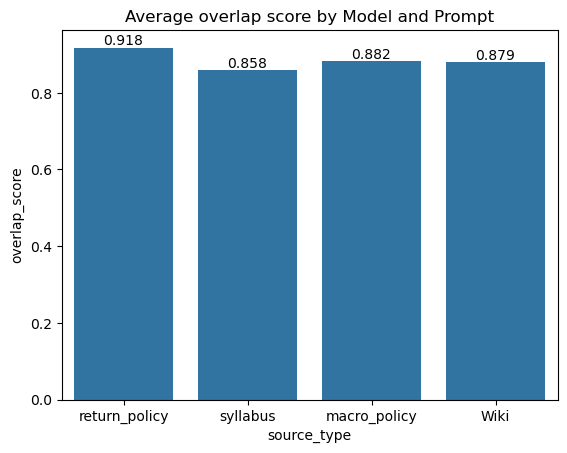

In [56]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="source_type",
    y="overlap_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Average overlap scorePrompt")

plt.show()

In [58]:
print(df_all.groupby(["model", "prompt_type"])["overlap_score"].mean())

model             prompt_type    
gemini-2.5-flash  baseline           0.971263
                  concise            0.957797
                  key_information    0.870358
gemini-2.5-pro    baseline           0.905853
                  concise            0.906622
                  key_information    0.762916
gpt-4o-mini       baseline           0.917319
                  concise            0.938877
                  key_information    0.822620
mistral-large     baseline           0.903982
                  concise            0.884327
                  key_information    0.724902
Name: overlap_score, dtype: float64


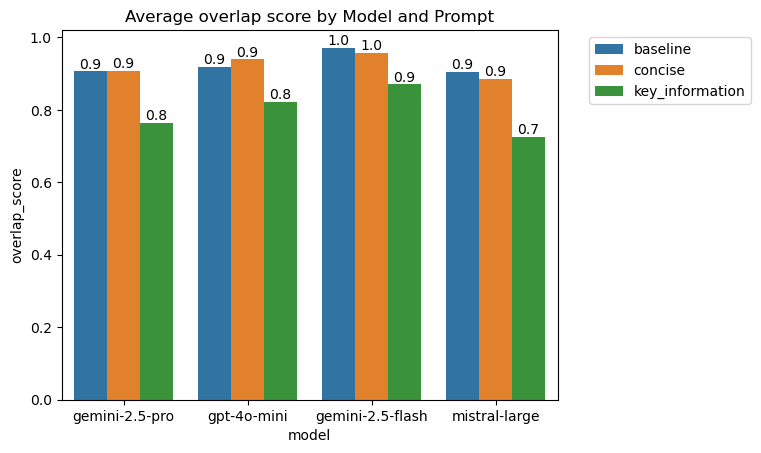

In [60]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="model",
    y="overlap_score",
    hue="prompt_type",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average overlap score by Model and Prompt")
plt.xticks()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


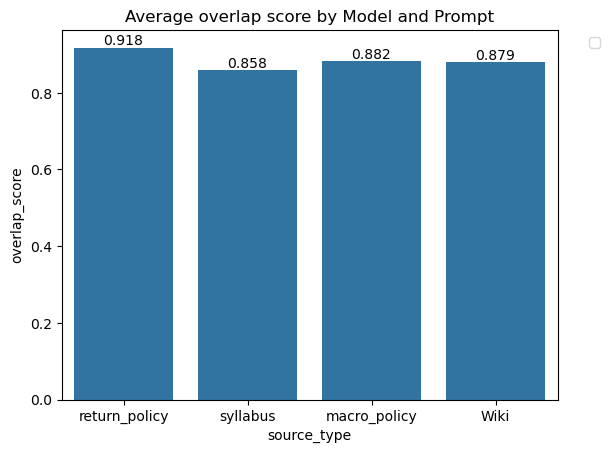

In [90]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="source_type",
    y="overlap_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average overlap score by Model and Prompt")
plt.xticks()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


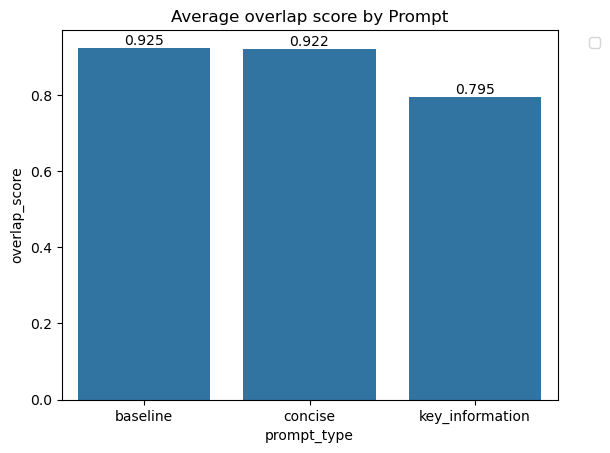

In [100]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="prompt_type",
    y="overlap_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average overlap score by Prompt")
plt.xticks()

plt.show()

#### Coverage Score

In [65]:
import re

stopwords = {
    "the","a","an","and","or","but","if","in","on","at","to","for","of","with",
    "by","is","are","was","were","be","been","being","this","that","these","those",
    "it","its","as","from","into","about","can","could","should","would","will",
    "may","might","do","does","did","have","has","had"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    return [w for w in words if w not in stopwords]

def coverage_score(row):
    text_words = set(clean_text(row["text"]))
    answer_words = set(clean_text(row["answer"]))
    if len(text_words) == 0:
        return 0
    return len(text_words & answer_words) / len(text_words)

df_all["coverage_score"] = df_all.apply(coverage_score, axis=1)

print("\nMean coverage score by model:")
print(df_all.groupby("model")["coverage_score"].mean().round(3))


Mean coverage score by model:
model
gemini-2.5-flash    0.050
gemini-2.5-pro      0.081
gpt-4o-mini         0.068
mistral-large       0.080
Name: coverage_score, dtype: float64


In [67]:
print(df_all.groupby("prompt_type")["coverage_score"].mean().round(3))

prompt_type
baseline           0.048
concise            0.042
key_information    0.120
Name: coverage_score, dtype: float64


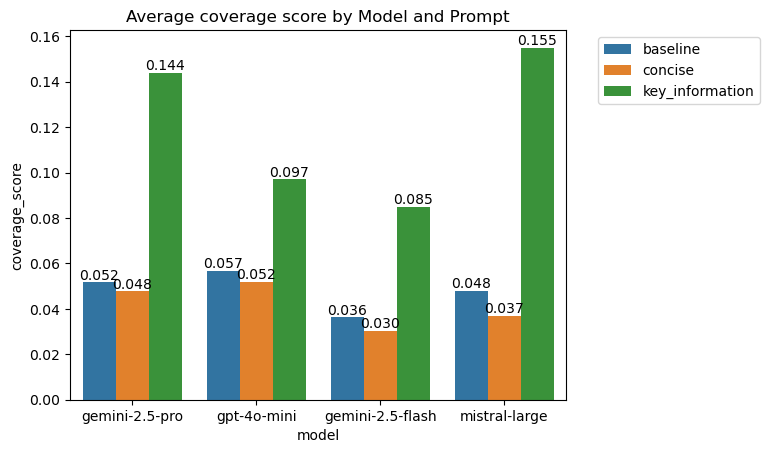

In [73]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="model",
    y="coverage_score",
    hue="prompt_type",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average coverage score by Model and Prompt")
plt.xticks()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


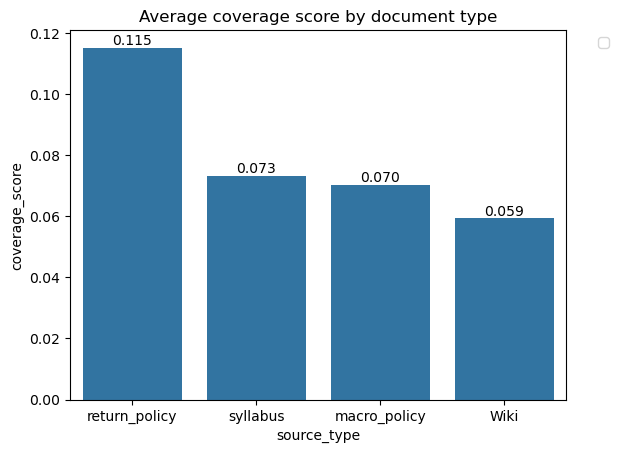

In [98]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="source_type",
    y="coverage_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average coverage score by document type")
plt.xticks()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


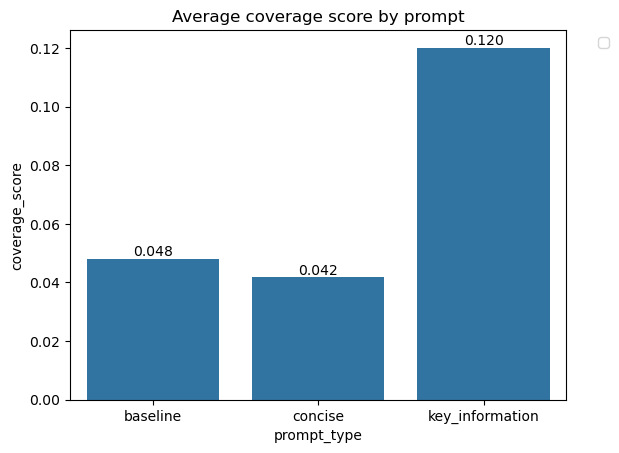

In [96]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="prompt_type",
    y="coverage_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average coverage score by prompt")
plt.xticks()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


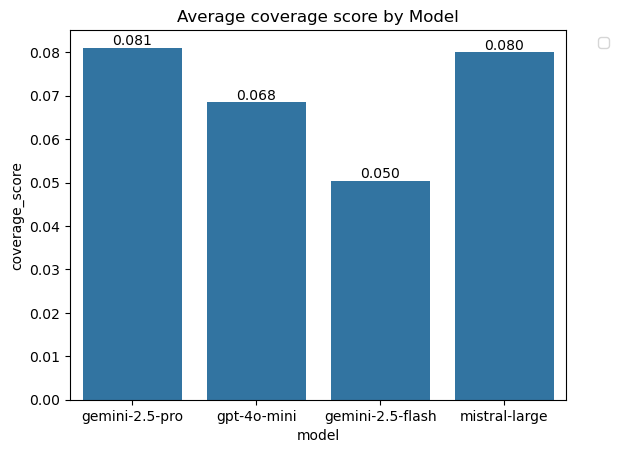

In [81]:
plt.figure()

ax = sns.barplot(
    data=df_all,
    x="model",
    y="coverage_score",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average coverage score by Model")
plt.xticks()

plt.show()

#### Human evaluation

In [7]:
import pandas as pd

df = pd.read_csv("results_all.csv")
df

,chunk_id,source_type,document,model,prompt_type,question,answer,Correctness,Question_Relevance,Information_Coverage
0,1,return_policy,Apple,gemini-2.5-pro,baseline,What is the time frame for returning an undama...,An undamaged product can be returned within 14...,10.0,9.0,NaN
1,2,return_policy,Apple,gemini-2.5-pro,baseline,What form of compensation is offered for an it...,Apple will offer an Apple Gift Card for items ...,NaN,NaN,NaN
2,3,return_policy,Apple,gemini-2.5-pro,baseline,What happens to your wireless service account ...,Returning your device may not automatically ca...,NaN,NaN,NaN
3,4,return_policy,Apple,gemini-2.5-pro,baseline,What happens if an iPhone requires repair due ...,The repair will not be covered under the warra...,10.0,10.0,10.0
4,5,return_policy,Apple,gemini-2.5-pro,baseline,What happens if Apple cancels an order after y...,Apple will refund the billed amount.,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1243,100,Wiki,Climate_change,mistral-large,baseline,What are the target years for Japan and China ...,"Japan aims to become carbon-neutral by 2050, a...",10.0,10.0,10.0
1244,101,Wiki,Climate_change,mistral-large,baseline,What percentage range of scientific consensus ...,98.7 to 100%.,NaN,NaN,NaN
1245,102,Wiki,Climate_change,mistral-large,baseline,What did Eunice Newton Foote demonstrate about...,She demonstrated that carbon dioxide has a hea...,NaN,NaN,NaN
1246,103,Wiki,Climate_change,mistral-large,baseline,What percentage of climate experts agreed that...,98.7%.,NaN,NaN,NaN


In [84]:
score_cols = ["Correctness", "Question_Relevance", "Information_Coverage"]

for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

eval_df = df.dropna(subset=score_cols, how="all").copy()

print("Total rows in original file:", len(df))
print("Rows included in manual evaluation analysis:", len(eval_df))
print()

KeyError: 'Correctness'

In [11]:
# ===== 4. Group by source_type =====
source_summary = eval_df.groupby("source_type")[score_cols].mean()

# ===== 5. Group by model =====
model_summary = eval_df.groupby("model")[score_cols].mean()

# ===== 6. Group by prompt_type =====
prompt_summary = eval_df.groupby("prompt_type")[score_cols].mean()

print("\n=== Mean scores by source_type ===")
print(source_summary.round(3))

print("\n=== Mean scores by model ===")
print(model_summary.round(3))

print("\n=== Mean scores by prompt_type ===")
print(prompt_summary.round(3))


=== Mean scores by source_type ===
               Correctness  Question_Relevance  Information_Coverage
source_type                                                         
Wiki                 9.792               9.750                 9.667
macro_policy         9.875               9.792                 9.542
return_policy        9.889               9.139                 9.542
syllabus            10.000               9.208                 9.448

=== Mean scores by model ===
                  Correctness  Question_Relevance  Information_Coverage
model                                                                  
gemini-2.5-flash        9.758               9.212                 9.433
gemini-2.5-pro          9.848               9.606                 9.429
gpt-4o-mini             9.879               9.545                 9.600
mistral-large          10.000               9.606                 9.833

=== Mean scores by prompt_type ===
                 Correctness  Question_Relevance  In

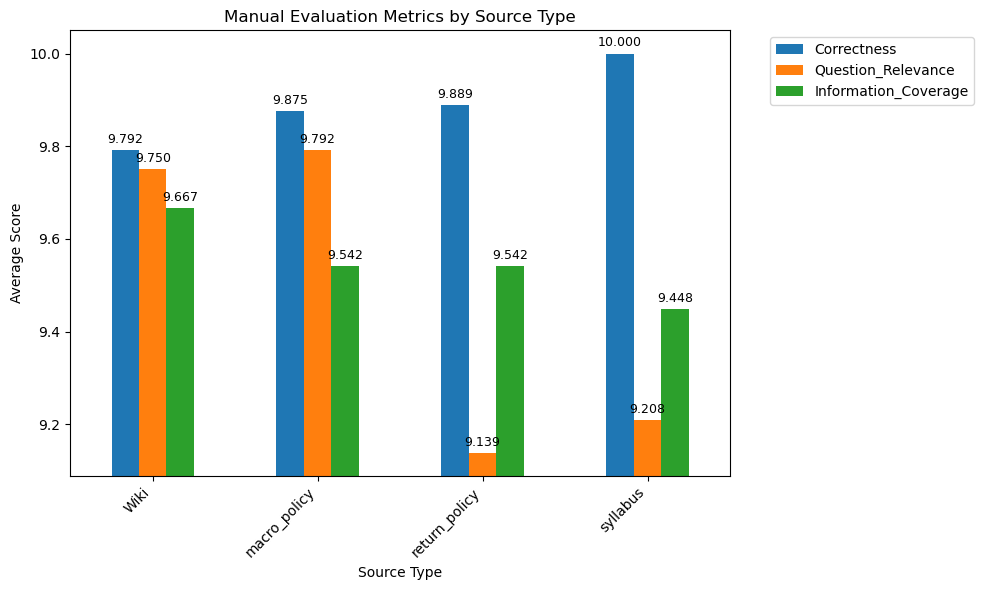

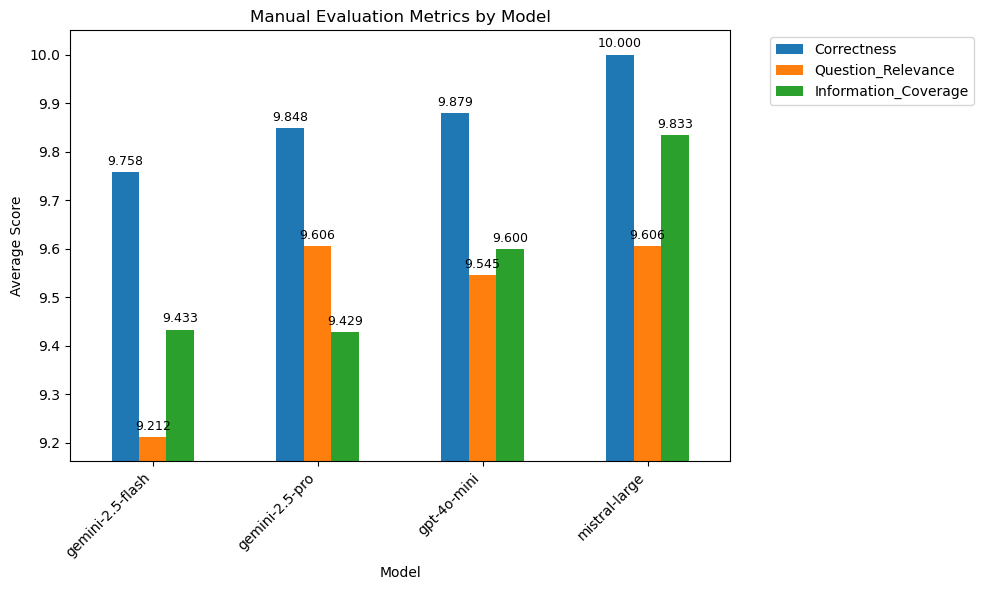

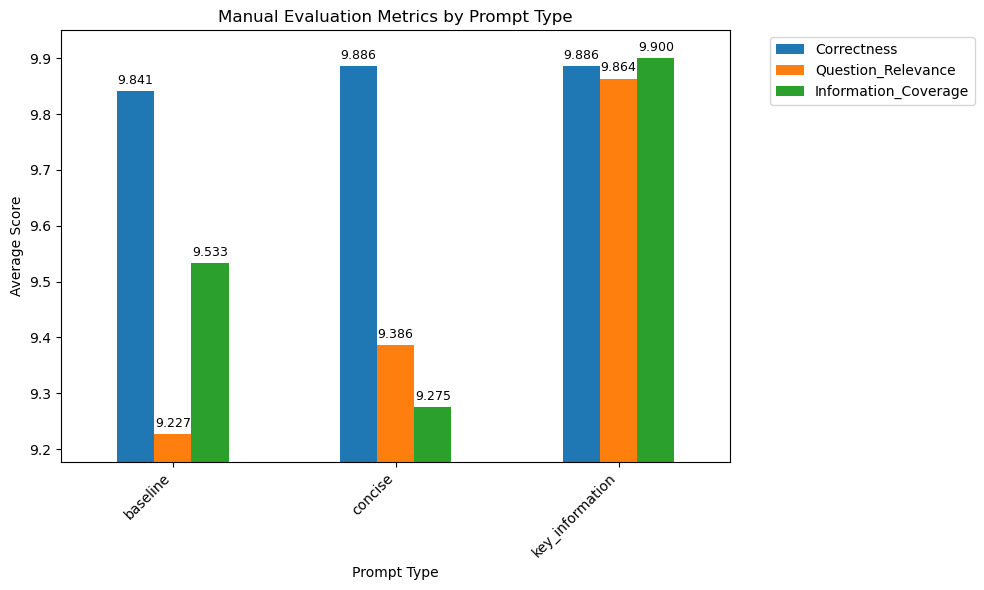

In [25]:
import matplotlib.pyplot as plt
# ===== 5. Function to add labels on bars =====
def add_bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)


# ===== 6. Plot: source_type =====
ax = source_summary.plot(kind="bar", figsize=(10, 6))
plt.title("Manual Evaluation Metrics by Source Type")
plt.xlabel("Source Type")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ymin = source_summary.min().min()
ymax = source_summary.max().max()
ax.set_ylim(ymin - 0.05, ymax + 0.05)

add_bar_labels(ax)
plt.tight_layout()
plt.show()

# ===== 7. Plot: model =====
ax = model_summary.plot(kind="bar", figsize=(10, 6))
plt.title("Manual Evaluation Metrics by Model")
plt.xlabel("Model")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ymin = model_summary.min().min()
ymax = model_summary.max().max()
ax.set_ylim(ymin - 0.05, ymax + 0.05)

add_bar_labels(ax)
plt.tight_layout()
plt.show()

# ===== 8. Plot: prompt_type =====
ax = prompt_summary.plot(kind="bar", figsize=(10, 6))
plt.title("Manual Evaluation Metrics by Prompt Type")
plt.xlabel("Prompt Type")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ymin = prompt_summary.min().min()
ymax = prompt_summary.max().max()
ax.set_ylim(ymin - 0.05, ymax + 0.05)

add_bar_labels(ax)
plt.tight_layout()
plt.show()